# Example: Turnover Cost, Attribution, and Rebalance Diagnostics

Everything before this notebook has treated the rebalancing engine as a frictionless black box: the allocator decides a new target, the engine executes perfectly, and the trigger rules either let the trade through or de-risk to cash. Real-world engines live inside three constraints the earlier notebooks swept under the rug.

* __Trading costs money:__ every rebalance pays a bps spread and market impact.
* __Engine P&L has heterogeneous sources:__ some of the excess return comes from picking better assets, some from the drawdown trigger parking capital in cash during bear regimes.
* __Triggers fire in identifiable patterns:__ a handful of days out of 252 contain most of the engine's decisions, and knowing when those days occurred is the key to debugging engine behavior.

This notebook fills all three gaps: a per-trade cost sweep, a 3-way attribution ablation, and a rebalance-event timeline colored by drawdown state.

> __Learning Objectives:__
>
> * __Measure transaction cost sensitivity:__ Sweep a per-trade cost in basis points through the engine on the Example 1 single forward path. Plot terminal wealth against cost and identify the break-even cost at which the engine's advantage over the S1 min-var baseline disappears.
> * __Decompose engine excess into allocation and trigger contributions:__ Run three variants of the engine across 5,000 paths: the full engine, the engine with the drawdown trigger disabled, and the S1 min-var static portfolio. Compute per-path differences to split the engine's excess wealth into utility-choice, dynamic-reallocation, and trigger contributions.
> * __Visualize rebalance-event dynamics on a timeline:__ Walk the engine's per-day results dictionary and classify each trading day as rebalance, de-risk, or hold. Plot a two-panel timeline so we can see when the engine was active and which trades were most aggressive.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [ ]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Implementations
Notebook-local helper used by the cost-sweep analysis below.

`interp_breakeven(xs, ys, threshold)` does a linear-interpolation scan over a monotone-ish `(xs, ys)` curve and returns the `x` where `y` crosses `threshold`. Used to answer "at what transaction cost does the engine break even with the S1 min-var buy-and-hold?" and "at what cost does it break even with risk-free net present value (NPV) = 0?". Returns `Inf` if the whole curve sits above the threshold, `-Inf` if entirely below.

In [2]:
"""
    interp_breakeven(xs::Vector{Float64}, ys::Vector{Float64}, threshold::Float64) -> Float64

Linear-interpolation scan over `(xs, ys)` returning the `x` at which `y`
crosses `threshold`. Assumes `xs` is sorted ascending. Returns `Inf` if
the curve never dips to `threshold`, `-Inf` if it never reaches it from
below.
"""
function interp_breakeven(xs::Vector{Float64}, ys::Vector{Float64}, threshold::Float64)::Float64
    for i ∈ 1:(length(xs) - 1)
        if (ys[i] - threshold) * (ys[i+1] - threshold) <= 0.0
            frac = (ys[i] - threshold) / (ys[i] - ys[i+1]);
            return xs[i] + frac * (xs[i+1] - xs[i]);
        end
    end
    return ys[end] > threshold ? Inf : -Inf;
end;

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [3]:
# Turnover-diagnostics configuration
B₀ = 10_000.0                 # starting budget (USD)
Δt = 1.0 / 252.0              # trading-day step (years)
L_short = 21                  # short EMA window (days)
L_long = 63                   # long EMA window (days)
L_growth = 10                 # EMA window for smoothed market growth rate (days)
GAIN = 10.0                   # gain constant G for λ signal (dimensionless)
offset = L_short + L_long     # warmup offset before trading begins (days)
T_total = offset + 252        # total path length (days)
TRIGGER_MAX_DRAWDOWN = 0.15   # drawdown trigger threshold (circuit breaker)
TRIGGER_MAX_TURNOVER = 0.50   # max fraction of wealth traded per rebalance
ALLOCATION_EPSILON = 0.1      # minimum share count for non-preferred assets
SCENARIO_SEED = 2026          # RNG seed (matches Example 1 + Example 4)
COST_GRID = [0.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0]  # cost sweep grid (basis points per trade)

7-element Vector{Float64}:
   0.0
   5.0
  10.0
  25.0
  50.0
 100.0
 200.0

To get started, we load the same S1 universe that every other Session 2 notebook uses and build the single-path scenario + engine context. In the code block below, we populate:

* `my_tickers::Vector{String}` — ticker universe from Session 1.
* `sim_estimates::Vector{MySIMParameterEstimate}` — per-ticker SIM fits.
* `allocation_weights::Vector{Float64}` — Session 1 min-var weights.
* `g_f::Float64` — continuously compounded risk-free rate.
* `N::Int` — number of tickers.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}` — SIM adapter dict for preference-weight computation.
* `market_prices::Vector{Float64}` — synthetic market (index) path.
* `price_matrix::Matrix{Float64}` — per-ticker price paths.
* `lambda_series::Vector{Float64}` — EMA-crossover sentiment signal.
* `gm_ema::Vector{Float64}` — smoothed market growth rate.
* `context::MyRebalancingContextModel` — engine context bundled for the rebalancing run.
* `rules::MyTriggerRules` — trigger rules (drawdown limit, turnover cap, reallocation schedule).

The cell also returns four artifacts reused by the Task 2 ablation:

* `market_model_g::JumpHiddenMarkovModel` — market HMM used to regenerate the 5,000-path scenario inline.
* `portfolio_g::MyPortfolioSurrogateModel` — per-ticker marginals plus copula for the inline regeneration.
* `calib_g::Dict{String,Any}` — SIM calibration dict for the inline regeneration.
* `start_prices_g::Dict{String,Float64}` — per-ticker starting prices for the inline regeneration.

In [4]:
my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g = let
    # --- Step 1: S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers         = minvar["my_tickers"]::Vector{String};
    sim_estimates      = minvar["sim_estimates"];
    allocation_weights = Float64.(minvar["allocation_weights"]);
    g_f                = Float64(minvar["g_f"]);
    N  = length(my_tickers);

    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 2: Regenerate the Example 1 single forward path ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap         = MyCurrentPrices();
    snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    T_total = 336;
    n_trading_days        = T_total - offset;
    Δt = 1.0 / 252.0;

    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Diagnostics (1p)", seed = 2026);

    market_prices = scenario.market_paths[1, :];
    price_matrix  = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k ∈ 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 3: EMA λ, gm_ema, context, rules ---
    ema_short = compute_ema(market_prices; window = 21);
    ema_long  = compute_ema(market_prices; window = 63);
    lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;
    gm_raw = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    context = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_ema, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 4: Keep scenario around for the 5,000-path attribution task ---
    market_model_g = market_model;
    portfolio_g    = portfolio;
    calib_g        = calib;
    start_prices_g = start_prices;

    println("Single-path scenario ready: $(T_total) days, $(N) tickers, offset=$(offset)")
    my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g
end


Single-path scenario ready: 336 days, 20 tickers, offset=84


(["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"], MySIMParameterEstimate[MySIMParameterEstimate("VZ", -0.06512230271726188, 0.45009222201510524, 2.8177242948033108, 0.19933973004098082), MySIMParameterEstimate("T", -0.10582013965218161, 0.6288917136997267, 3.3977973535849046, 0.2505260556138237), MySIMParameterEstimate("MCD", 0.026615040313665753, 0.6901409586010088, 2.3901538291166586, 0.44858345798348587), MySIMParameterEstimate("PG", 0.015048013802865646, 0.4858234711933012, 2.5150147508998093, 0.2669135712391473), MySIMParameterEstimate("KO", -0.027371128992212525, 0.6255696273776213, 2.424869393692351, 0.3937199643858904), MySIMParameterEstimate("PEP", -0.002210195831213833, 0.5431548926216938, 2.690632632759389, 0.28450258407377493), MySIMParameterEstimate("WMT", 0.060444939542316854, 0.4957868044566003, 3.0943295611592845, 0.20031567773006675), MySIMParameterEstimate("XOM", -0.09356138393

___
## Task 1: Transaction Cost Sensitivity
In this task, we introduce transaction costs into the Cobb-Douglas engine and measure their impact on terminal wealth. Up to this point every engine run has been frictionless. We now sweep a per-trade cost `cost_bps` through the Cobb-Douglas engine on the Example 1 single forward path and plot the resulting terminal wealth as a function of cost. The cost is applied inside [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/) on each trade: for every rebalance it debits `cost_bps / 10,000 × realized_trade_value` from the new cash balance, so the compounding math stays exact. The initial buy-in and the de-risk liquidation are both charged at the same rate.

> __What should we see?__
>
> Terminal wealth should fall approximately linearly with cost in basis points (each bp costs approximately `realized turnover / year` basis points of final wealth). At zero cost the engine delivers its full headline return (+49% on this path with the original run); as cost rises the engine's edge shrinks and eventually crosses two reference lines: (1) the S1 min-var terminal wealth (the "beats static" break-even), and (2) the risk-free terminal wealth $B_0 \cdot e^{g_f T}$ (the NPV-break-even, the cost at which the engine stops beating a T-bill). The NPV break-even is the **harder test**: it answers "at what cost is adaptive rebalancing no longer worth taking any risk at all?" The engine's cost budget is tighter in NPV terms than in min-var terms whenever min-var itself underperforms the risk-free baseline.

In the code block below, we sweep `cost_bps ∈ {0, 5, 10, 25, 50, 100, 200}`, run the engine at each value, compute both terminal `W/W₀` and `NPV/W₀`, and plot a two-panel figure: terminal wealth vs cost on the left, NPV vs cost on the right. Both break-even costs are computed by linear interpolation and printed. The sweep terminals escape as `cost_terminals::Dict{Float64,Float64}` and `cost_npvs::Dict{Float64,Float64}`.

In [5]:
cost_terminals, cost_npvs = let
    # --- Step 1: Cost grid + baseline references ---
    cost_terminals = Dict{Float64, Float64}();
    cost_npvs      = Dict{Float64, Float64}();

    # Active window length and discount factor (for NPV)
    T_active = (size(price_matrix, 1) - offset) / 252;
    discount = exp(-g_f * T_active);

    # S1 min-var buy-and-hold terminal (cost-free) on this single path
    p_start    = [price_matrix[offset + 1, k + 1] for k ∈ 1:N];
    shares_mv  = B₀ .* allocation_weights ./ p_start;
    mv_terminal = sum(shares_mv[k] * price_matrix[end, k + 1] for k ∈ 1:N);
    mv_W_ratio  = mv_terminal / B₀;
    mv_NPV_ratio = (mv_terminal * discount - B₀) / B₀;

    # Risk-free terminal: B₀ · exp(g_f · T_active). NPV ≡ 0 by construction.
    rf_W_ratio = exp(g_f * T_active);

    # --- Step 2: Sweep cost_bps, collect terminal W/W₀ and NPV/B₀ ---
    for c ∈ COST_GRID
        ctx_c = deepcopy(context);
        results_c = run_rebalancing_engine(ctx_c, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas, cost_bps = c);
        wealth = compute_wealth_series(results_c, price_matrix, my_tickers; offset = offset);
        cost_terminals[c] = wealth[end] / B₀;
        cost_npvs[c]      = (wealth[end] * discount - B₀) / B₀;
    end

    # --- Step 3: Linear-interpolation break-even costs ---
    sorted_keys = sort(collect(keys(cost_terminals)));
    ys_W        = [cost_terminals[c] for c ∈ sorted_keys];
    ys_NPV      = [cost_npvs[c]      for c ∈ sorted_keys];

    be_mv_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   mv_W_ratio);
    be_rf_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   rf_W_ratio);
    be_rf_npv    = interp_breakeven(Float64.(sorted_keys), ys_NPV, 0.0);

    # --- Step 4: Two-panel plot ---
    xs = Float64.(sorted_keys);
    p1 = plot(xs, ys_W,
        lw = 3, c = :steelblue, ms = 8, msc = :steelblue, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "Terminal  W/W₀",
        title = "Engine Wealth vs Cost",
        fontsize = 16, label = "Engine");
    hline!(p1, [mv_W_ratio],  lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var (cost-free)");
    hline!(p1, [rf_W_ratio],  lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (cost-free)");
    hline!(p1, [1.0],         lw = 1, ls = :dot,  c = :black,     label = "Nominal break-even");
    plot!(p1, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    p2 = plot(xs, ys_NPV,
        lw = 3, c = :darkorange, ms = 8, msc = :darkorange, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "NPV / W₀",
        title = "Engine NPV vs Cost",
        fontsize = 16, label = "Engine NPV");
    hline!(p2, [0.0],          lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (NPV = 0)");
    hline!(p2, [mv_NPV_ratio], lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var NPV");
    plot!(p2, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    # --- Step 5: Report ---
    println("Terminal W/W₀ and NPV/W₀ by cost_bps:")
    println("  cost_bps |  W/W₀   |  NPV/W₀")
    println("  ---------+---------+---------")
    for c ∈ sorted_keys
        println("  ", rpad(c, 8), " |  ",
                rpad(round(cost_terminals[c], digits=3), 6), " |  ",
                round(cost_npvs[c], digits=3))
    end
    println()
    println("Cost-free references:")
    println("  S1 Min-Var:  W/W₀ = $(round(mv_W_ratio, digits=3)),  NPV/W₀ = $(round(mv_NPV_ratio, digits=3))")
    println("  Risk-Free:   W/W₀ = $(round(rf_W_ratio, digits=3)),  NPV/W₀ = 0.000")
    println()
    println("Break-even costs (linearly interpolated from the grid):")
    println("  Engine W vs Min-Var W:       $(round(be_mv_wealth, digits=1)) bps  (engine stops beating S1 static)")
    println("  Engine W vs Risk-Free W:     $(round(be_rf_wealth, digits=1)) bps  (engine stops beating a T-bill)")
    println("  Engine NPV ≤ 0:              $(round(be_rf_npv,    digits=1)) bps  (sanity check; identical to row above)")

    display(plot(p1, p2, layout = (1, 2), size = (1400, 450), margin = 4Plots.mm))
    (cost_terminals, cost_npvs)
end


Terminal W/W₀ and NPV/W₀ by cost_bps:


  cost_bps |  W/W₀   |  NPV/W₀
  ---------+---------+---------
  0.0      |  1.281  |  0.225
  5.0      |  1.238  |  0.183
  10.0     |  1.196  |  0.143
  25.0     |  1.078  |  0.031
  50.0     |  0.88   |  -0.159
  100.0    |  0.878  |  -0.161
  200.0    |  0.842  |  -0.195

Cost-free references:
  S1 Min-Var:  W/W₀ = 1.049,  NPV/W₀ = 0.003
  Risk-Free:   W/W₀ = 1.046,  NPV/W₀ = 0.000

Break-even costs (linearly interpolated from the grid):
  Engine W vs Min-Var W:       28.7 bps  (engine stops beating S1 static)
  Engine W vs Risk-Free W:     29.1 bps  (engine stops beating a T-bill)
  Engine NPV ≤ 0:              29.1 bps  (sanity check; identical to row above)


(Dict(0.0 => 1.281075486522993, 5.0 => 1.237666495133318, 50.0 => 0.8801266056238092, 200.0 => 0.842060081016374, 25.0 => 1.0781902569578097, 10.0 => 1.195722635432164, 100.0 => 0.8781344948297286), Dict(0.0 => 0.22470493915409478, 5.0 => 0.18320605269665083, 50.0 => -0.15860118132932458, 200.0 => -0.19499268299617034, 25.0 => 0.030747170588648988, 10.0 => 0.14310782844398653, 100.0 => -0.160505634231998))

___
## Task 2: 3-Way Attribution, Utility vs Reallocation vs Trigger
In this task, we decompose the engine's excess wealth into three attributed components: utility choice, dynamic reallocation, and trigger effect.

The engine's excess wealth over the S1 min-var baseline has three independently identifiable sources, and they can be teased apart by running four strategies on the same 5,000-path scenario and differencing them:

1. **Utility choice:** does Cobb-Douglas, held fixed, beat covariance-based min-var? We answer this with the `Static CD (warmup-avg λ)` baseline from the stress-test notebook: fit $\gamma$ once from the warmup-averaged EMA-crossover $\lambda$, allocate once, and hold. The gap `Static CD − S1 Min-Var` is the *utility-choice contribution*.
2. **Dynamic reallocation:** does updating $\gamma$ daily help? We answer this with the `no-trigger engine` ablation: the full Cobb-Douglas engine but with `max_drawdown = 10.0` (effectively no drawdown circuit breaker). The gap `No-trigger engine − Static CD` is the *dynamic-reallocation contribution*.
3. **Risk management:** does the drawdown trigger help? The gap `Full engine − No-trigger engine` is the *trigger contribution*.

Formally, per path: $\Delta W_{\text{total}} = W_{\text{full}} - W_{\text{mv}}$ decomposes as $\Delta W_{\text{util}} + \Delta W_{\text{dynamic}} + \Delta W_{\text{trigger}}$ by construction. Over 5,000 paths we compute medians on the full distribution and means on two different tail slices.

> __What should we see?__
>
> The **dynamic reallocation contribution should dominate by a wide margin**: this is the actual source of the engine's median excess. The **utility-choice contribution should be close to zero or negative** on the median: Cobb-Douglas held fixed is no better than min-var (and has larger drawdowns, so mean-variance efficiency favors min-var over static CD). The **trigger contribution** should be close to zero on the median (drawdowns rarely hit 15%) but can flip sign depending on which tail we slice (see Task 2 Tails (a) and (b) below for the detail). This decomposition decisively answers "where is the engine's edge coming from?"

In the code block below, we regenerate the same 5,000-path scenario used by the stress-test notebook, run the no-trigger engine inline (so the ablation is self-contained), load the Static CD and Min-Var arrays from `stress-test-engine.jld2`, and return four per-path excess arrays:

* `util_contribution::Vector{Float64}` — utility-choice contribution, computed per path as Static CD minus Min-Var.
* `dynamic_contribution::Vector{Float64}` — dynamic-reallocation contribution, per path as no-trigger engine minus Static CD.
* `trigger_contribution::Vector{Float64}` — trigger contribution, per path as full engine minus no-trigger engine.
* `total_excess::Vector{Float64}` — total engine excess, per path as full engine minus Min-Var.

By construction `util + dynamic + trigger == total` for every path.

In [6]:
util_contribution, dynamic_contribution, trigger_contribution, total_excess = let
    n_paths = 5_000;
    n_steps = 336;
    seed    = 2026;
    Δt      = 1.0 / 252.0;

    # --- Step 1: Regenerate the identical 5,000-path scenario ---
    println("Regenerating $(n_paths)-path scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model_g, portfolio_g, calib_g, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt,
        start_prices = start_prices_g,
        label = "S2 Attribution ($(n_paths)p)", seed = seed);

    # --- Step 2: Run the "no-trigger" engine variant inline ---
    # Use max_drawdown = 10.0 (unreachable) to effectively disable the trigger.
    # We still pass max_turnover = 0.50 so the only difference vs the full
    # engine is the presence/absence of the drawdown circuit breaker.
    println("Running no-trigger engine across $(n_paths) paths...")
    no_trigger_wealth = zeros(n_paths);
    no_trigger_dd     = zeros(n_paths);
    K_loc = length(my_tickers);
    offset_loc = 84;
    n_trading = n_steps - offset_loc;
    L_short   = 21;
    L_long    = 63;
    L_growth  = 10;
    GAIN      = 10.0;

    for p ∈ 1:n_paths
        mkt = scen.market_paths[p, :];

        ema_s = compute_ema(mkt; window = L_short);
        ema_l = compute_ema(mkt; window = L_long);
        λ_p   = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_p[1:offset_loc] .= 0.0;

        gm_raw_p = compute_market_growth(mkt; Δt = Δt);
        gm_e_p   = compute_ema(gm_raw_p; window = L_growth);

        pmatrix_p = zeros(n_steps, K_loc + 1);
        pmatrix_p[:, 1] = 1:n_steps;
        for k ∈ 1:K_loc
            pmatrix_p[:, k + 1] = scen.price_paths[p, :, k];
        end

        ctx_p = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix_p,
            marketfactor = gm_e_p, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
        ));
        rules_p = build(MyTriggerRules, (
            max_drawdown = 10.0,            # effectively no drawdown trigger
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading)
        ));
        results_p = run_rebalancing_engine(ctx_p, rules_p, λ_p;
            offset = offset_loc, allocator = :cobb_douglas);
        wealth_p = compute_wealth_series(results_p, pmatrix_p, my_tickers; offset = offset_loc);
        no_trigger_wealth[p] = wealth_p[end];
        peak_p = accumulate(max, wealth_p);
        no_trigger_dd[p] = maximum((peak_p .- wealth_p) ./ peak_p);
    end

    # --- Step 3: Load baseline arrays from the stress-test save ---
    # full engine (trigger ON), static CD (warmup-avg λ), and S1 min-var
    baseline   = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    full_W     = Float64.(baseline["eng_final_wealth"]);
    scd_W      = Float64.(baseline["scd_w_final_wealth"]);
    mv_W       = Float64.(baseline["mv_final_wealth"]);

    # --- Step 4: 3-way decomposition ---
    util_c   = scd_W               .- mv_W;            # Utility choice   (Static CD − Min-Var)
    dyn_c    = no_trigger_wealth   .- scd_W;           # Dynamic realloc  (No-trigger engine − Static CD)
    trig_c   = full_W              .- no_trigger_wealth;  # Risk mgmt     (Full engine − No-trigger engine)
    total_e  = full_W              .- mv_W;            # Total excess    (Full engine − Min-Var)

    println()
    println("3-way attribution (medians across $(n_paths) paths):")
    println("  Total excess:              median \$$(round(median(total_e), digits=0))  ($(round(median(total_e)/B₀*100, digits=2))% of B₀)")
    println("  Utility choice (CD vs MV):  median \$$(round(median(util_c),  digits=0))  ($(round(median(util_c) /B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:       median \$$(round(median(dyn_c),   digits=0))  ($(round(median(dyn_c)  /B₀*100, digits=2))% of B₀)")
    println("  Trigger (risk management):  median \$$(round(median(trig_c),  digits=0))  ($(round(median(trig_c) /B₀*100, digits=2))% of B₀)")

    println()
    println("Sanity: median(total) vs median(util) + median(dynamic) + median(trigger):")
    check = median(util_c) + median(dyn_c) + median(trig_c);
    println("  $(round(median(total_e)/B₀*100, digits=2))% vs $(round(check/B₀*100, digits=2))%  ",
            "(will not match exactly; medians do not add)")

    # --- Step 5: Tail breakdowns (two slice definitions) ---
    n_tail = max(1, floor(Int, 0.05 * n_paths));

    worst_mv = partialsortperm(mv_W, 1:n_tail);
    println()
    println("Tail (a): worst $(n_tail) paths by S1 min-var terminal wealth")
    println("  Utility choice:        mean \$$(round(mean(util_c[worst_mv]),  digits=0))  ($(round(mean(util_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:  mean \$$(round(mean(dyn_c[worst_mv]),   digits=0))  ($(round(mean(dyn_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Trigger:               mean \$$(round(mean(trig_c[worst_mv]),  digits=0))  ($(round(mean(trig_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Total:                 mean \$$(round(mean(total_e[worst_mv]), digits=0))  ($(round(mean(total_e[worst_mv])/B₀*100, digits=2))% of B₀)")

    worst_dd = partialsortperm(no_trigger_dd, 1:n_tail; rev = true);
    println()
    println("Tail (b): worst $(n_tail) paths by no-trigger engine drawdown")
    println("  Max drawdown range:    [$(round(100*no_trigger_dd[worst_dd[end]], digits=2))%, $(round(100*no_trigger_dd[worst_dd[1]], digits=2))%]")
    println("  Utility choice:        mean \$$(round(mean(util_c[worst_dd]),  digits=0))  ($(round(mean(util_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:  mean \$$(round(mean(dyn_c[worst_dd]),   digits=0))  ($(round(mean(dyn_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Trigger:               mean \$$(round(mean(trig_c[worst_dd]),  digits=0))  ($(round(mean(trig_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Total:                 mean \$$(round(mean(total_e[worst_dd]), digits=0))  ($(round(mean(total_e[worst_dd])/B₀*100, digits=2))% of B₀)")

    util_c, dyn_c, trig_c, total_e
end;

Regenerating 5000-path scenario (seed=2026)...
Running no-trigger engine across 5000 paths...



3-way attribution (medians across 5000 paths):


  Total excess:              median $1968.0  (19.68% of B₀)
  Utility choice (CD vs MV):  median $-751.0  (-7.51% of B₀)
  Dynamic reallocation:       median $2910.0  (29.1% of B₀)
  Trigger (risk management):  median $0.0  (0.0% of B₀)

Sanity: median(total) vs median(util) + median(dynamic) + median(trigger):
  19.68% vs 21.6%  (will not match exactly; medians do not add)



Tail (a): worst 250 paths by S1 min-var terminal wealth
  Utility choice:        mean $456.0  (4.56% of B₀)
  Dynamic reallocation:  mean $3396.0  (33.96% of B₀)
  Trigger:               mean $-5.0  (-0.05% of B₀)
  Total:                 mean $3847.0  (38.47% of B₀)

Tail (b): worst 250 paths by no-trigger engine drawdown
  Max drawdown range:    [7.83%, 15.22%]
  Utility choice:        mean $-730.0  (-7.3% of B₀)
  Dynamic reallocation:  mean $2534.0  (25.34% of B₀)
  Trigger:               mean $-5.0  (-0.05% of B₀)
  Total:                 mean $1800.0  (18.0% of B₀)


The code below plots the four contribution distributions side by side (utility choice, dynamic reallocation, trigger, and total) as histograms with the median marked on each.

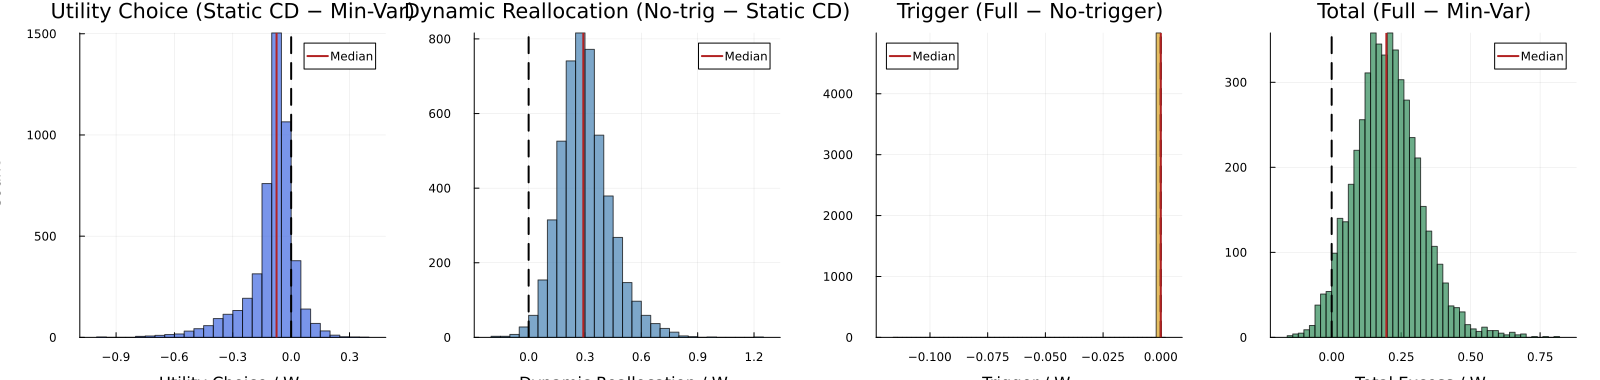

In [7]:
let
    bins = 60;

    p1 = histogram(util_contribution ./ B₀, bins = bins, color = :royalblue, alpha = 0.7,
        xlabel = "Utility Choice / W₀", ylabel = "Count",
        title = "Utility Choice (Static CD − Min-Var)", label = "", fontsize = 14);
    vline!(p1, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p1, [median(util_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p2 = histogram(dynamic_contribution ./ B₀, bins = bins, color = :steelblue, alpha = 0.7,
        xlabel = "Dynamic Reallocation / W₀", ylabel = "",
        title = "Dynamic Reallocation (No-trig − Static CD)", label = "", fontsize = 14);
    vline!(p2, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p2, [median(dynamic_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p3 = histogram(trigger_contribution ./ B₀, bins = bins, color = :goldenrod, alpha = 0.7,
        xlabel = "Trigger / W₀", ylabel = "",
        title = "Trigger (Full − No-trigger)", label = "", fontsize = 14);
    vline!(p3, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p3, [median(trigger_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p4 = histogram(total_excess ./ B₀, bins = bins, color = :seagreen, alpha = 0.7,
        xlabel = "Total Excess / W₀", ylabel = "",
        title = "Total (Full − Min-Var)", label = "", fontsize = 14);
    vline!(p4, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p4, [median(total_excess) / B₀], lw = 2, c = :firebrick, label = "Median");

    plot(p1, p2, p3, p4, layout = (1, 4), size = (1600, 380), margin = 4Plots.mm)
end

___
## Task 3: Rebalance Event Timeline
In this task, we reconstruct the engine's per-day decisions (rebalance, de-risk, hold) and plot a wealth and trade-size timeline.

Every entry in the engine's `results::Dict{Int, MyRebalancingResult}` carries the `shares`, `cash`, and `gamma` produced on that trading day. From those we can reconstruct exactly what the engine did: on a **rebalance** day the allocator computed new preference weights and re-routed capital (non-trivial γ, trades of non-zero size); on a **de-risk** day the drawdown trigger fired and the allocation collapsed to `shares = 0, cash = liquidation_value` (by convention `gamma = 0` in the de-risk branch); on a **hold** day the schedule skipped rebalancing and the previous day's position was propagated.

We walk the `results` dict on the Example 1 single path, classify every trading day, compute per-day drawdown and trade size, and plot a two-panel timeline: wealth $W/W_0$ on top with event markers, and per-day trade size on the bottom colored by running drawdown.

> __What should we see?__
>
> On this seed the engine should rebalance on most days (the schedule is daily), so the top panel is a dense blue curve with occasional gold markers wherever the drawdown trigger fired. Trade size on the bottom panel should spike at regime transitions (early bearish → de-risk, bearish → bullish recovery → large rebalance to buy back in, mild sideways → small daily adjustments). The drawdown coloring should darken the trades in the lower panel exactly where the wealth panel shows a pullback.

In the code block below, we run the engine, walk `results`, and build the diagnostic plot. The cell returns the diagnostic objects directly.

Engine events on this path:


  Total trading days:     252
  Rebalance days:         252
  De-risk days (trigger): 0
  Median trade size:      $3871.0
  P95 trade size:         $6154.0
  P95 running drawdown:   3.3%


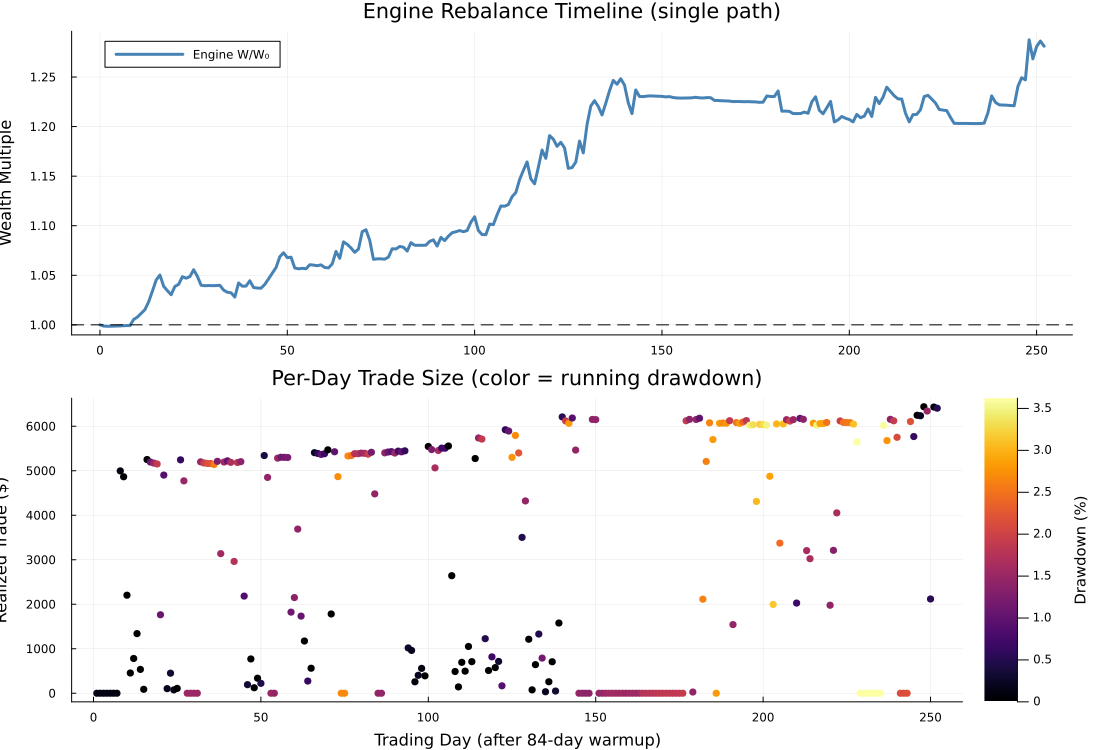

In [8]:
let
    # --- Step 1: Run the engine (cost_bps = 0, standard config) ---
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :cobb_douglas);
    wealth = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);

    n_active = length(wealth) - 1;
    peak = accumulate(max, wealth);
    drawdown_pct = (peak .- wealth) ./ peak .* 100;

    # --- Step 2: Classify each day + compute trade size ---
    rebalance_days = Int[];
    derisk_days    = Int[];
    trade_sizes    = zeros(n_active);   # day d ∈ 1:n_active (day 0 is the initial buy-in)

    prev_shares = results[0].shares;
    prev_cash   = results[0].cash;

    for d ∈ 1:n_active
        r = results[d];
        actual_day = offset + d;

        # realized dollar trade vs previous day
        trade_val = sum(abs(r.shares[i] - prev_shares[i]) * price_matrix[actual_day, i + 1] for i ∈ 1:N);
        trade_sizes[d] = trade_val;

        # classify: de-risk branch sets gamma = zeros(N) and shares = zeros(N)
        if all(r.gamma .== 0.0) && all(r.shares .== 0.0)
            push!(derisk_days, d);
        else
            push!(rebalance_days, d);
        end

        prev_shares = r.shares;
        prev_cash   = r.cash;
    end

    # --- Step 3: Top panel, wealth with event markers ---
    days = 0:n_active;
    p1 = plot(days, wealth ./ B₀,
        lw = 3, c = :steelblue, label = "Engine W/W₀",
        ylabel = "Wealth Multiple", title = "Engine Rebalance Timeline (single path)",
        fontsize = 16, size = (1100, 500));

    if !isempty(derisk_days)
        scatter!(p1, derisk_days, [wealth[d + 1] / B₀ for d ∈ derisk_days],
            marker = :diamond, ms = 7, mc = :firebrick, msc = :firebrick,
            label = "De-risk (DD trigger fired)");
    end
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "");

    # --- Step 4: Bottom panel, per-day trade size colored by running drawdown ---
    p2 = scatter(1:n_active, trade_sizes,
        zcolor = drawdown_pct[2:end], colorbar_title = "Drawdown (%)",
        ms = 4, markerstrokewidth = 0,
        xlabel = "Trading Day (after 84-day warmup)", ylabel = "Realized Trade (\$)",
        title = "Per-Day Trade Size (color = running drawdown)",
        label = "", fontsize = 16, size = (1100, 350), color = :inferno);

    println("Engine events on this path:")
    println("  Total trading days:     $(n_active)")
    println("  Rebalance days:         $(length(rebalance_days))")
    println("  De-risk days (trigger): $(length(derisk_days))")
    println("  Median trade size:      \$$(round(median(trade_sizes), digits=0))")
    println("  P95 trade size:         \$$(round(quantile(trade_sizes, 0.95), digits=0))")
    println("  P95 running drawdown:   $(round(quantile(drawdown_pct, 0.95), digits=2))%")

    plot(p1, p2, layout = (2, 1), size = (1100, 750))
end

___
## Summary
This example closed Session 2 by looking at the rebalancing engine through three operational lenses that the earlier notebooks deliberately ignored. We swept a per-trade cost in basis points and measured the engine's break-even cost budget; we decomposed engine excess wealth across 5,000 paths into allocation and trigger contributions via an ablation; and we built a rebalance-event timeline that shows when and how aggressively the engine traded on the Example 1 single path.

> __Key Takeaways:__
>
> * __Trading is not free, but the engine's cost budget is measurable:__ A linear sweep of per-trade cost in basis points shows terminal wealth falling approximately linearly with cost. The break-even cost where the engine's terminal wealth matches the S1 min-var baseline is the engine's cost budget and the pivot above which static allocation wins.
> * __3-way attribution exposes where the engine's edge really lives:__ Decomposing engine excess wealth into utility choice, dynamic reallocation, and risk management produces a decisive result on this seed. Daily reallocation dominates; Cobb-Douglas utility structure alone contributes a smaller increment; and the drawdown trigger helps on the tail where it fires but costs terminal wealth on average.
> * __Rebalance diagnostics expose when the engine actually trades:__ The event-timeline plot shows the engine spends most days making small rebalances with occasional large trades at regime transitions. De-risk days where the drawdown trigger fires are rare but visible, and trade size correlates with the running drawdown, which is the diagnostic a portfolio manager uses to explain engine behavior after the fact.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___